# Heart Disease Prediction
## Notebook 9: SHAP Interpretability Analysis

This notebook applies SHAP (SHapley Additive exPlanations) to interpret the
predictions of all three trained models. TreeExplainer is used for Random Forest
and XGBoost. LinearExplainer is used for Logistic Regression. Summary plots show
both feature importance and direction of impact. Waterfall plots explain
individual high-confidence predictions. Cross-model feature ranking reveals
which clinical variables consistently drive predictions across model architectures.

In [1]:
import os
import shap
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
MODELS_DIR = os.path.join("..", "models")
DATA_DIR = os.path.join("..", "data", "processed", "splits")

best_rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
best_xgb = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
best_lr = joblib.load(os.path.join(MODELS_DIR, "logistic_regression.pkl"))

X_train_tree = pd.read_csv(os.path.join(DATA_DIR, "X_train_tree.csv"))
X_test_tree = pd.read_csv(os.path.join(DATA_DIR, "X_test_tree.csv"))
X_train_lr = pd.read_csv(os.path.join(DATA_DIR, "X_train_lr.csv"))
X_test_lr = pd.read_csv(os.path.join(DATA_DIR, "X_test_lr.csv"))

shap.initjs()

In [3]:
explainer_rf = shap.TreeExplainer(model=best_rf, data=X_train_tree)
explainer_xgb = shap.TreeExplainer(model=best_xgb, data=X_train_tree, model_output="probability")
explainer_lr = shap.LinearExplainer(model=best_lr, masker=X_train_lr)

shap_values_rf = explainer_rf(X_test_tree)
shap_values_xgb = explainer_xgb(X_test_tree)
shap_values_lr = explainer_lr(X_test_lr)

### Random Forest SHAP Analysis

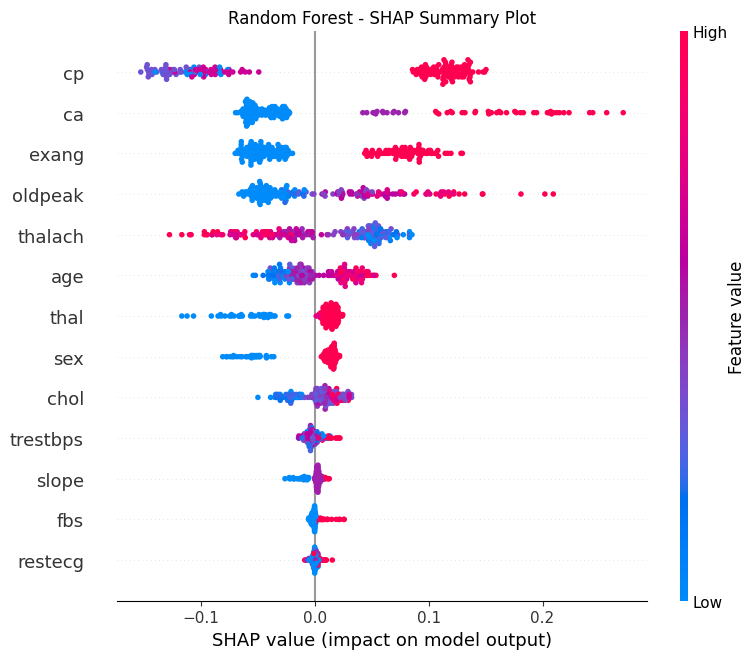

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf[:, :, 1], X_test_tree, show=False)
plt.title("Random Forest - SHAP Summary Plot")
plt.tight_layout()
plt.show()
plt.close()

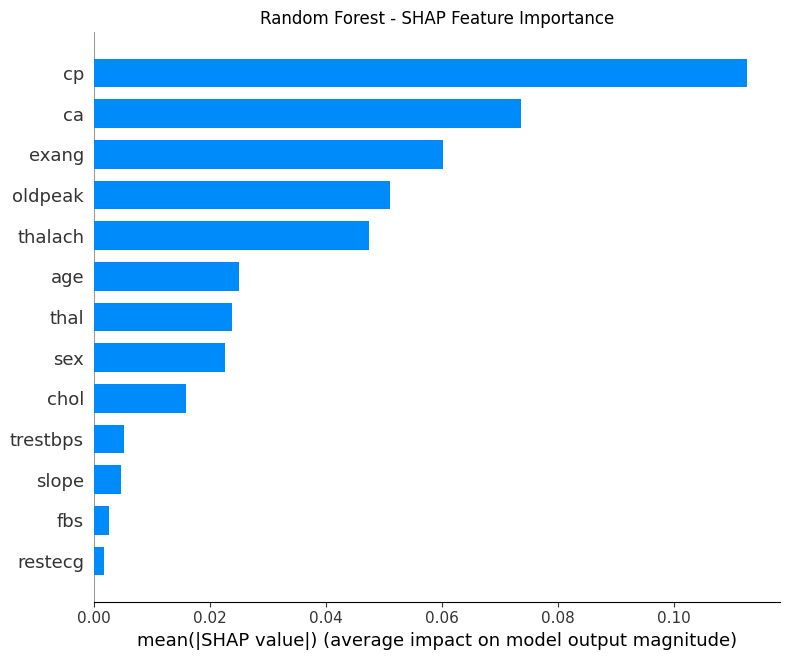

In [5]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf[:, :, 1], X_test_tree, plot_type="bar", show=False)
plt.title("Random Forest - SHAP Feature Importance")
plt.tight_layout()
plt.show()
plt.close()

### XGBoost SHAP Analysis

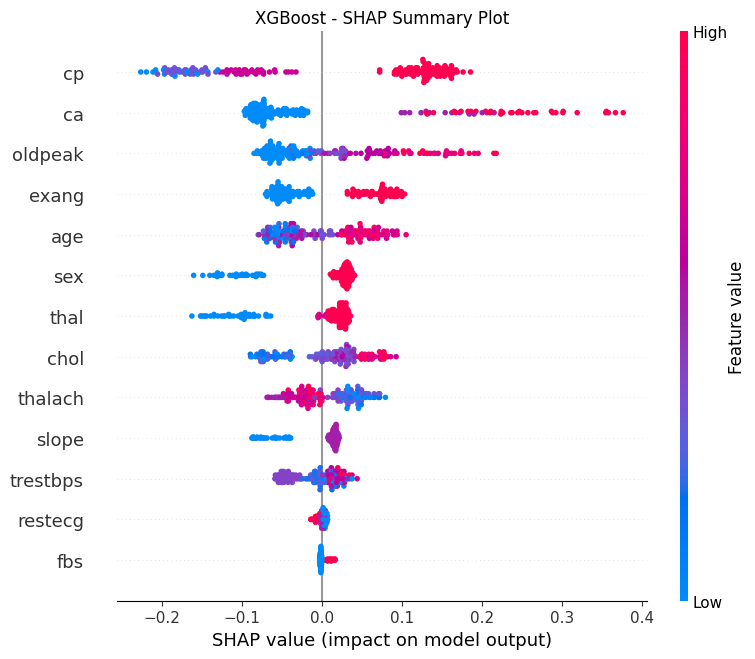

In [6]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test_tree, show=False)
plt.title("XGBoost - SHAP Summary Plot")
plt.tight_layout()
plt.show()
plt.close()

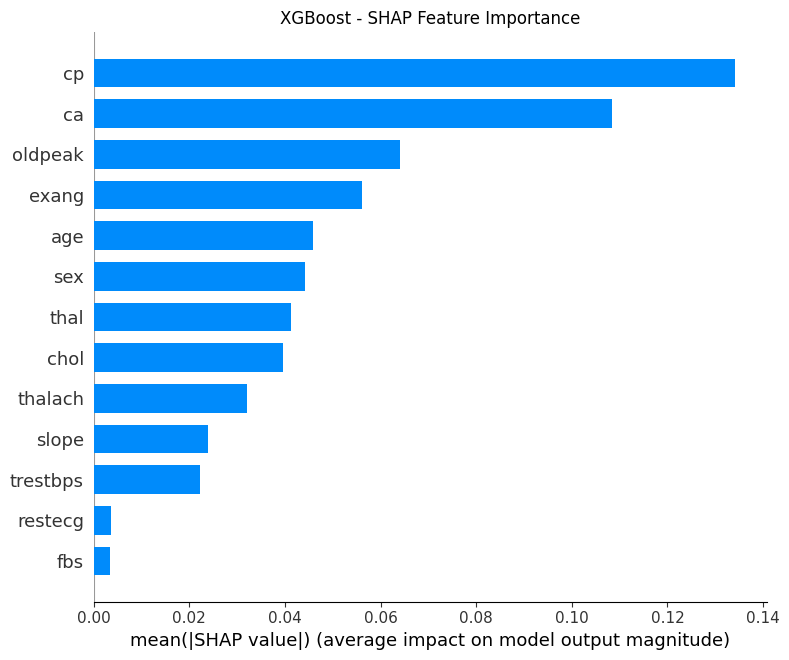

In [7]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test_tree, plot_type="bar", show=False)
plt.title("XGBoost - SHAP Feature Importance")
plt.tight_layout()
plt.show()
plt.close()

### Logistic Regression SHAP Analysis

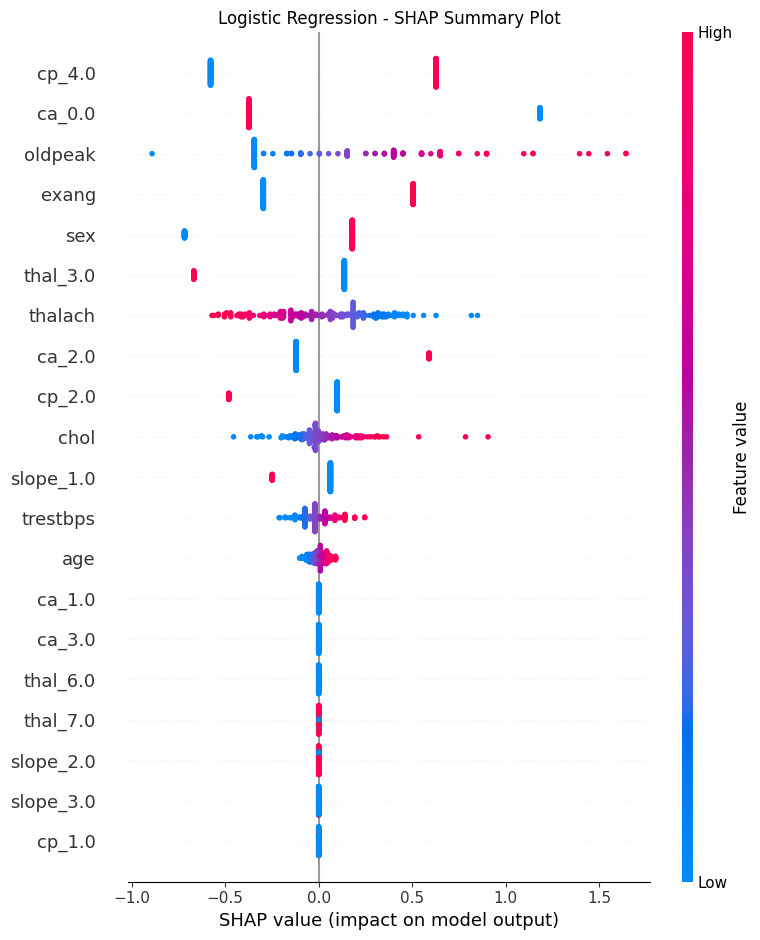

In [8]:
shap.summary_plot(shap_values_lr, X_test_lr, show=False)
plt.title("Logistic Regression - SHAP Summary Plot")
plt.tight_layout()
plt.show()
plt.close()

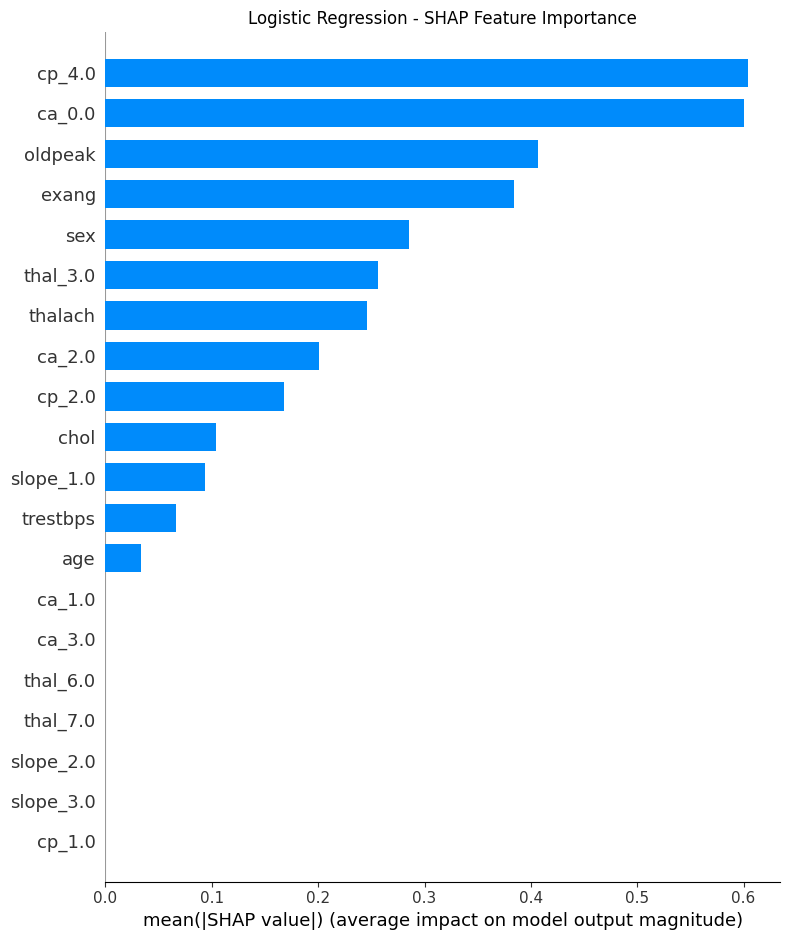

In [9]:
shap.summary_plot(shap_values_lr, X_test_lr, plot_type="bar", show=False)
plt.title("Logistic Regression - SHAP Feature Importance")
plt.tight_layout()
plt.show()
plt.close()

### Individual Prediction Explanation (Waterfall Plots)

The waterfall plots below explain the model's most confident disease prediction,
showing how each feature value pushed the prediction from the baseline probability
to the final output for a single high-risk patient.

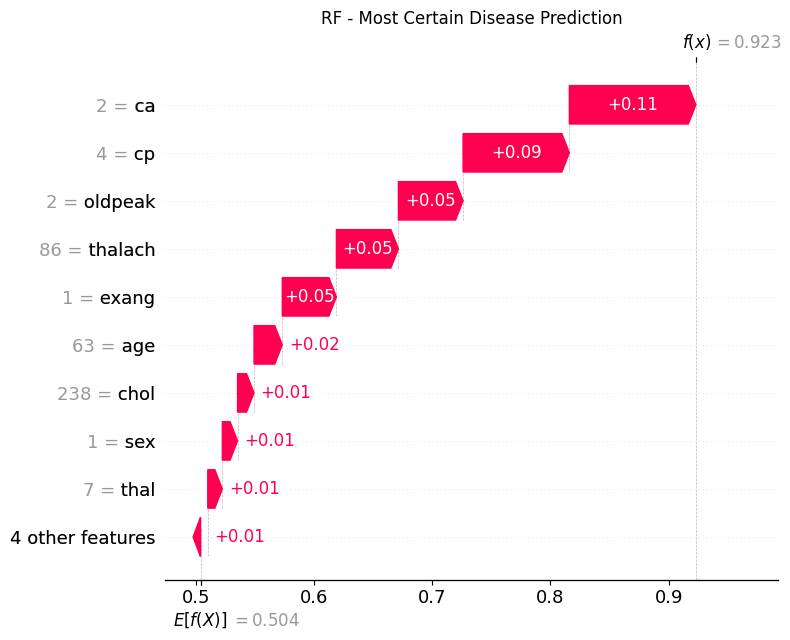

In [10]:
most_certain_rf = best_rf.predict_proba(X_test_tree)[:, 1].argmax()

shap.waterfall_plot(shap_values_rf[most_certain_rf, :, 1], show=False)
plt.title("RF - Most Certain Disease Prediction")
plt.tight_layout()
plt.show()
plt.close()

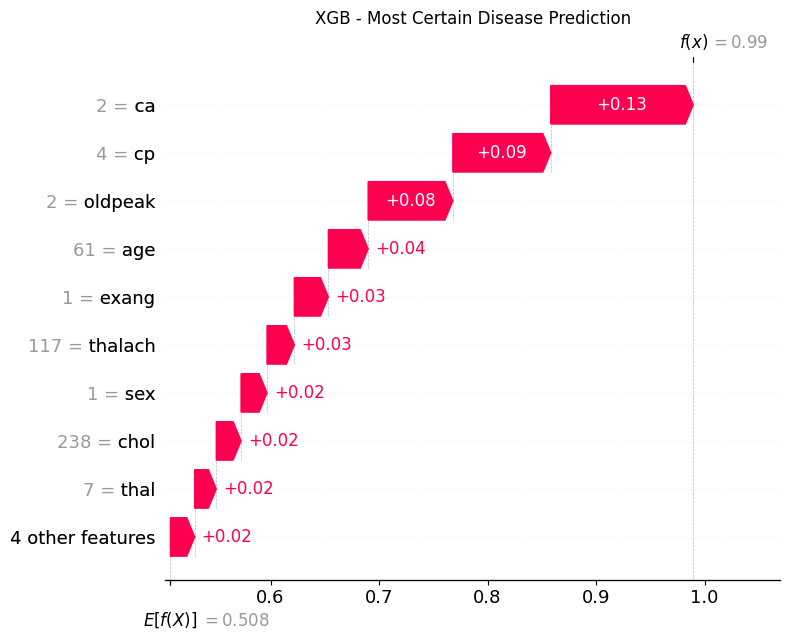

In [11]:
most_certain_xgb = best_xgb.predict_proba(X_test_tree)[:, 1].argmax()

shap.waterfall_plot(shap_values_xgb[most_certain_xgb], show=False)
plt.title("XGB - Most Certain Disease Prediction")
plt.tight_layout()
plt.show()
plt.close()

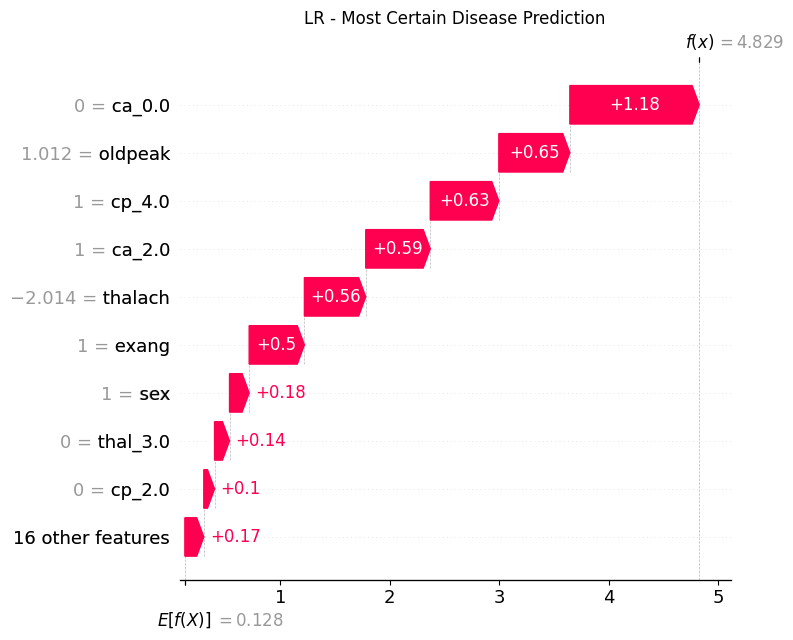

In [12]:
most_certain_lr = best_lr.predict_proba(X_test_lr)[:, 1].argmax()

shap.waterfall_plot(shap_values_lr[most_certain_lr], show=False)
plt.title("LR - Most Certain Disease Prediction")
plt.tight_layout()
plt.show()
plt.close()

### Cross-Model Feature Importance Comparison

The table below ranks features by mean absolute SHAP value across Random Forest, XGBoost, and Logistic Regression. Consistent ranking across all three model architectures indicates genuine clinical predictive value rather than model-specific artefacts.

In [13]:
rf_importance = pd.Series(
    np.abs(shap_values_rf.values[:, :, 1]).mean(axis=0),
    index=X_test_tree.columns
).sort_values(ascending=False)

xgb_importance = pd.Series(
    np.abs(shap_values_xgb.values).mean(axis=0),
    index=X_test_tree.columns
).sort_values(ascending=False)

lr_importance = pd.Series(
    np.abs(shap_values_lr.values).mean(axis=0),
    index=X_test_lr.columns
).sort_values(ascending=False)

print("RF top 5:", rf_importance.head().index.tolist())
print("XGB top 5:", xgb_importance.head().index.tolist())
print("LR top 5:", lr_importance.head().index.tolist())

RF top 5: ['cp', 'ca', 'exang', 'oldpeak', 'thalach']
XGB top 5: ['cp', 'ca', 'oldpeak', 'exang', 'age']
LR top 5: ['cp_4.0', 'ca_0.0', 'oldpeak', 'exang', 'sex']


## Key Findings

### Consistent Predictors Across All Three Models

The feature cp (chest pain type 4, asymptomatic presentation) is the strongest
single predictor across RF, XGBoost, and LR. The feature ca (number of vessels
coloured) strongly increases predicted disease risk at higher values. The features
oldpeak (ST depression), exang (exercise-induced angina), and thalach (maximum
heart rate) consistently appear in the top five across all models.

### Model-Specific Observations

XGBoost SHAP values show significantly larger magnitudes than Random Forest,
indicating overconfident individual predictions consistent with its higher false
negative count on the test set. Logistic Regression L1 regularisation zeroed out
seven features including ca_1.0, ca_3.0, thal_6.0, thal_7.0, slope_2.0,
slope_3.0, and cp_1.0, confirmed by their zero SHAP values. Random Forest
produces the most calibrated probability estimates with a baseline near 0.504.

### Waterfall Interpretation

The most certain Random Forest prediction involves a 63-year-old male with ca=2,
asymptomatic chest pain (cp=4), low maximum heart rate (thalach=86), and
exercise-induced angina present. Every clinical indicator aligns with high disease
risk, producing a 92.3% predicted probability. XGBoost predicts 98.8% for a
similar patient profile, consistent with its tendency toward overconfidence.

### Clinical Conclusion

Five features consistently drive predictions across all models: cp, ca, oldpeak,
exang, and thalach. These align with established cardiovascular risk factors in
clinical literature. The features restecg, fbs, and slope contribute minimal
predictive value, consistent with their near-zero correlations observed in the
EDA notebook.